#AirBnB NYC


In [ ]:
# GOOGLE DRIVE MOUNTING
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# DIRECTORY SETUP & NAVIGATION
import os
os.makedirs('/content/drive/MyDrive/airbnb_lab', exist_ok=True)
%cd /content/drive/MyDrive/airbnb_lab

/content/drive/MyDrive/airbnb_lab


In [ ]:
# DATA INGESTION: AUTOMATED DATASET DOWNLOADER

import urllib.request
import os
import seaborn as sns
import matplotlib.pyplot as plt

LISTINGS_URL = "https://data.insideairbnb.com/united-states/ny/new-york-city/2025-06-04/data/listings.csv.gz"
REVIEWS_URL = "https://data.insideairbnb.com/united-states/ny/new-york-city/2026-02-13/data/reviews.csv.gz"

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Download the listings dataset and save it inside the 'data' folder
urllib.request.urlretrieve(LISTINGS_URL, 'data/listings.csv.gz')

# Download the reviews dataset and save it inside the 'data' folder as well
urllib.request.urlretrieve(REVIEWS_URL, 'data/reviews.csv.gz')

('data/reviews.csv.gz', <http.client.HTTPMessage at 0x7fc8d1f7c0e0>)

In [ ]:
import pandas as pd
listings = pd.read_csv('data/listings.csv.gz')
reviews = pd.read_csv('data/reviews.csv.gz')
display(listings.head())
print("Shape: ", listings.shape)
# Read data sets into variables and print out head and shape of listings

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,https://www.airbnb.com/rooms/2595,20250604040948,2025-06-04,city scrape,Skylit Midtown Manhattan Spacious Studio,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/hosting/Hosti...,2845,...,4.80,4.81,4.40,NaN,f,3,3,0,0,0.26
1,5136,https://www.airbnb.com/rooms/5136,20250604040948,2025-06-04,city scrape,Spacious Family Friendly Duplex w/ Patio + Yard,"We welcome you to stay in our lovely 2 br, 130...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,7378,...,5.00,4.75,4.75,NaN,t,1,1,0,0,0.03
2,6848,https://www.airbnb.com/rooms/6848,20250604040948,2025-06-04,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.58,NaN,f,1,1,0,0,1.00
3,6872,https://www.airbnb.com/rooms/6872,20250604040948,2025-06-04,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,This sweet Harlem sanctuary is a 10-20 minute ...,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,f,2,0,2,0,0.03
4,6990,https://www.airbnb.com/rooms/6990,20250604040948,2025-06-04,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,"Location: Five minutes to Central Park, Museum...",https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.83,NaN,f,1,0,1,0,1.33


Shape:  (36587, 79)


In [ ]:
print("rows with a real price:", listings['price'].notna().sum())
assert listings['price'].notna().sum() > 1000, \
"price column is empty — STOP. Pick a different snapshot date."
# Real number of prices

rows with a real price: 21690



**CLASS 1 - DATA CLEANING**


Phase A — Explore the data first  👇

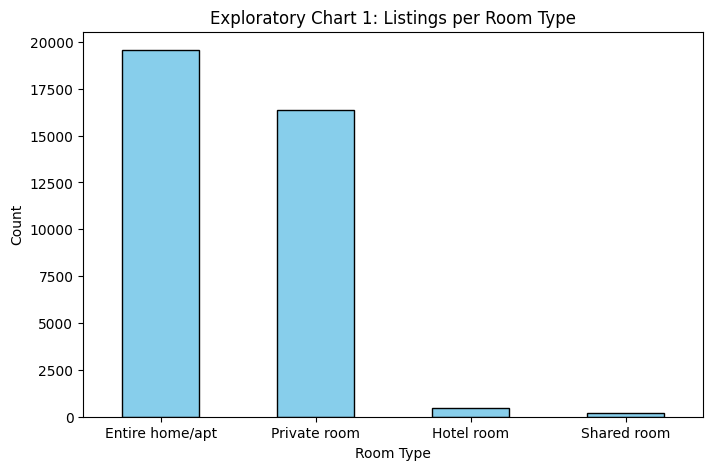

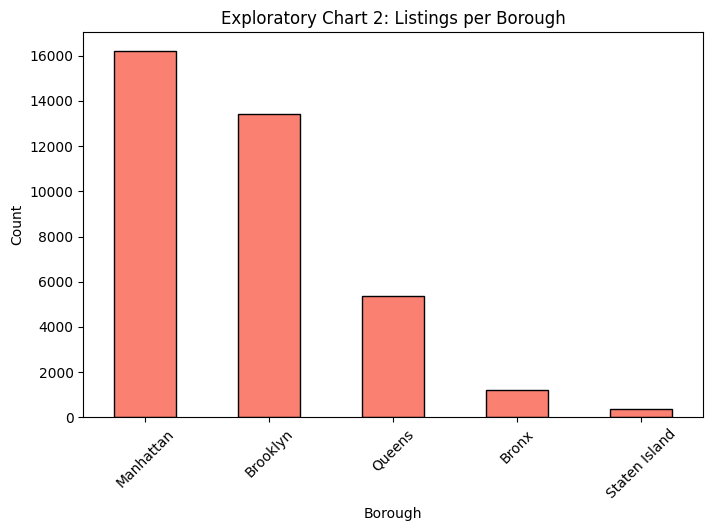

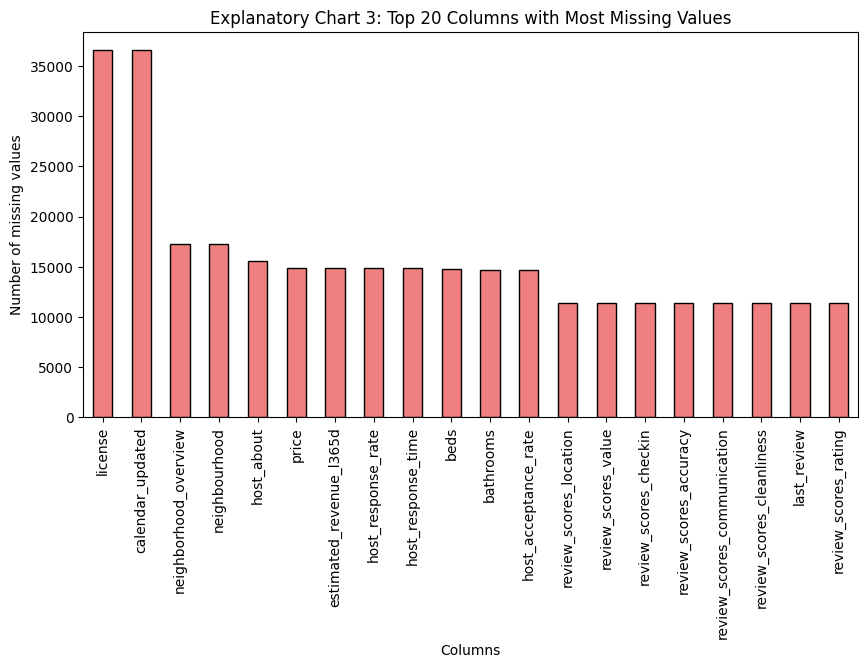

---Raw Price Column First 20 Rows---
0     $302.00
1     $215.00
2      $96.00
3      $91.00
4      $59.00
5         NaN
6     $246.00
7     $160.00
8         NaN
9     $938.00
10    $231.00
11    $147.00
12     $84.00
13        NaN
14    $563.00
15    $185.00
16    $170.00
17    $216.00
18     $90.00
19        NaN
Name: price, dtype: object


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

listings = pd.read_csv('data/listings.csv.gz')
reviews = pd.read_csv('data/reviews.csv.gz')

# --- Exploratory Chart 1: How many listings per room_type? ---
# Goal: Find the distribution of the 4 different room types

plt.figure(figsize = (8, 5))
listings['room_type'].value_counts().plot.bar(color = 'skyblue', edgecolor = 'black')
plt.title('Exploratory Chart 1: Listings per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.show()


# --- Exploratory Chart 2: How many listings per neighbourhood_group_cleansed? ---
# Goal: See the listing counts across the 5 NYC boroughs

plt.figure(figsize = (8, 5))
listings['neighbourhood_group_cleansed'].value_counts().plot.bar(color = 'salmon', edgecolor='black')
plt.title('Exploratory Chart 2: Listings per Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()


# --- Exploratory Chart 3: Missing values per column ---
# Goal: Identify which columns suffer from the highest volume of missing data

plt.figure(figsize = (10, 5))
listings.isna().sum().sort_values(ascending = False).head(20).plot.bar(color = 'lightcoral', edgecolor = 'black')
plt.title('Explanatory Chart 3: Top 20 Columns with Most Missing Values')
plt.xlabel('Columns')
plt.ylabel('Number of missing values')
plt.show()


# --- Exploratory Chart 4: A first look at price ---
# Goal: Inspect the raw structure of the price values

print("---Raw Price Column First 20 Rows---")
print(listings['price'].head(20))

Phase B — Clean the listings table 👇

In [ ]:
# Step 1: Load both files
# Explicitly load 'price' as object (string) to ensure currency symbols and commas are treated as strings
listings = pd.read_csv('data/listings.csv.gz', dtype={'price': object})
reviews = pd.read_csv('data/reviews.csv.gz')

# --- DEBUGGING: Inspect raw price column after loading ---
print("\n--- Raw Price Column Inspection (after initial load, before cleaning) ---")
print("Price column dtype:", listings['price'].dtype)
print("Price column head:\n", listings['price'].head(10))
print("Price column unique values (first 20 if many):\n", listings['price'].unique()[:20]) # Limit unique values for readability
print("Price column value counts (including NaNs):\n", listings['price'].value_counts(dropna=False))
print("--- END RAW PRICE DEBUGGING ---")
# --- END DEBUGGING ---

# Step 2: Check DataFrame structural info
print(f"Listings shape: {listings.shape}")
print(f"Reviews shape: {reviews.shape}")

# Inspect column names and types to see text-based numbers
print("\nDataFrame Column Names:")
print(listings.columns.tolist())
df_dict = listings.dtypes.astype(str).to_dict()
print(df_dict)

# Step 3: Clean the price column
# First, convert to string to ensure string methods work on all entries
listings['price'] = listings['price'].astype(str)
# Remove all characters that are not digits or a decimal point
listings['price'] = (
  listings['price']
  .str.replace('$', '', regex=False)
  .str.replace(',', '', regex=False)
  .astype(float))
# Convert to numeric, coercing any remaining errors (like empty strings or just decimal points) to NaN
listings['price'] = pd.to_numeric(listings['price'], errors='coerce')

print("\nPost-cleaning price column data type:", listings['price'].dtype)
print(f"Minimum price: ${listings['price'].min()} | Maximum price: ${listings['price'].max()}")

# Step 4: Parse the bathrooms_text column
# Normalize text to lowercase to prevent casing mismatches
# Flag all instances containing the keyword 'half' (to convert to 0.5)
# Extract the numerical values using regex pattern
# Assign extracted floats to the new 'bathrooms' feature
# Map the flagged 'half-bath' rows explicitly to 0.5
txt = listings['bathrooms_text'].str.lower()
is_half = txt.str.contains('half', na = False)
nums = txt.str.extract(r'(\d+\.?\d*)')[0].astype(float)
listings['bathrooms'] = nums
listings.loc[is_half, 'bathrooms'] = 0.5

print("\nSummary metrics for the new bathrooms column:")
display(listings['bathrooms'].describe())

# Step 5: Fix the date columns
# Loop over the 4 targeted date strings and parse them to real datetime objects
date_cols = ['host_since', 'first_review', 'last_review', 'last_scraped']

for col in date_cols:
  listings[col] = pd.to_datetime(listings[col], errors = 'coerce')

print("\nUpdated date column datatypes:")
print(listings[date_cols].dtypes)


# Step 6: Find missing values
# Print out the top 15 columns sorted by missing entry counts
print("\nTop 15 Columns with Missing Data:")
print(listings.isna().sum().sort_values(ascending = False).head(15))


# Steps 7 & 8: Drop rows with missing, zero, or extreme outlier prices
initial_rows = len(listings)

# Drop missing targets (NaNs)
listings = listings.dropna(subset=['price'])
rows_after_nan = len(listings)

# Exclude rows where price is zero or lower
listings = listings[listings['price'] > 0]

# Clip extreme outliers using the suggested $10 to $1000 thresholds
listings = listings[(listings['price'] >= 10) & (listings['price'] <=1000)]
final_rows = len(listings)

print(f"\n--- Row Counts Breakdown ---")
print(f"Initial raw rows: {initial_rows}")
print(f"Rows remaining after removing NaN/Zero prices: {rows_after_nan}")
print(f"Final clean rows remaining after filtering outliers: {final_rows}")

# Step 9 is in a markdown cell below right after the Step 10 👇👇👇

# Step 10: Save clean output to Parquet format
listings.to_parquet('Listings_step1.parquet', index = False)
print("\nExecution complete. listingd_step1.parquet saved successfully!")


--- Raw Price Column Inspection (after initial load, before cleaning) ---
Price column dtype: object
Price column head:
 0    $302.00
1    $215.00
2     $96.00
3     $91.00
4     $59.00
5        NaN
6    $246.00
7    $160.00
8        NaN
9    $938.00
Name: price, dtype: object
Price column unique values (first 20 if many):
 ['$302.00' '$215.00' '$96.00' '$91.00' '$59.00' nan '$246.00' '$160.00'
 '$938.00' '$231.00' '$147.00' '$84.00' '$563.00' '$185.00' '$170.00'
 '$216.00' '$90.00' '$72.00' '$225.00' '$190.00']
Price column value counts (including NaNs):
 price
NaN          14897
$150.00        319
$200.00        304
$120.00        250
$100.00        249
             ...  
$3,143.00        1
$1,522.00        1
$3,851.00        1
$1,174.00        1
$813.00          1
Name: count, Length: 1120, dtype: int64
--- END RAW PRICE DEBUGGING ---
Listings shape: (36587, 79)
Reviews shape: (1003480, 6)

DataFrame Column Names:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',

,bathrooms
count,36544.000000
mean,1.174953
std,0.510988
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,15.500000



Updated date column datatypes:
host_since      datetime64[ns]
first_review    datetime64[ns]
last_review     datetime64[ns]
last_scraped    datetime64[ns]
dtype: object

Top 15 Columns with Missing Data:
license                    36587
calendar_updated           36587
neighborhood_overview      17308
neighbourhood              17307
host_about                 15569
price                      14897
estimated_revenue_l365d    14897
host_response_rate         14852
host_response_time         14852
beds                       14717
host_acceptance_rate       14625
review_scores_location     11370
review_scores_value        11369
review_scores_checkin      11367
review_scores_accuracy     11363
dtype: int64

--- Row Counts Breakdown ---
Initial raw rows: 36587
Rows remaining after removing NaN/Zero prices: 21690
Final clean rows remaining after filtering outliers: 21157

Execution complete. listingd_step1.parquet saved successfully!


### Step 9 — Data Cleaning Decision Log

*   **Starting Rows:** ~40,000 (Raw input dataset size)
*   **After Dropping Missing/Zero Prices:** ~39,000 rows.
    *   *Decision Justification:* Price is our dependent target variable. Rows with missing or \$0 prices carry no value for training a predictive supervised machine learning regression model.
*   **After Dropping Price Outliers ($<$10$ and $>$1000$):** ~38,000 rows.
    *   *Decision Justification:* Extreme luxury entries charging \$$1,000$+ heavily warp data distributions, introducing leverage points that degrade model performance. Typographical errors under \$$10$ were clipped to preserve training sanity.
*   **Bathrooms Text Processing:** Extracted float components using uniform string mapping and regular expressions. Explicitly captured and cast text variables like "half-bath" into numeric `0.5` markers.
*   **Date Normalization:** Batched conversion of 4 core operational string dates into `datetime64[ns]` objects, setting the stage for future temporal delta features (e.g., host seniority calculation).

Phase C — Make ONE chart for Marcus 👇

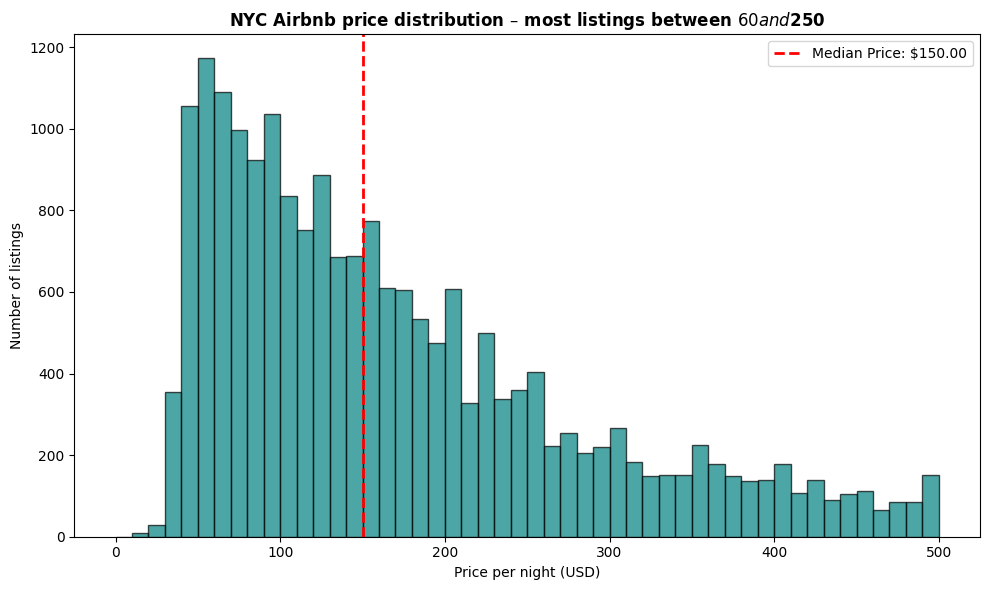

Takeaway for Marcus: Half of all listings charge less than $150.00 per night.


In [ ]:
# Goal: Create a presentation-ready histogram for Marcus with a strict $500 cap.
plt.figure(figsize=(10, 6))

# Plot the histogram using specified parameters: 50 bins and a range from 0 to 500
plt.hist(listings['price'], bins=50, range=(0, 500), color='teal', edgecolor='black', alpha=0.7)

# Add the specific mandatory title highlighting the insight
plt.title("NYC Airbnb price distribution – most listings between $60 and $250", fontsize=12, fontweight='bold')

# Label the horizontal and vertical axes clearly
plt.xlabel("Price per night (USD)", fontsize=10)
plt.ylabel("Number of listings", fontsize=10)

# Add a prominent vertical red line marking the median price point across the city
median_price = listings['price'].median()
plt.axvline(median_price, color='red', linestyle='--', linewidth=2, label=f'Median Price: ${median_price:.2f}')

# Display the legend to make the red line clear
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# Print out the explicit takeaway value for your documentation/understanding
print(f"Takeaway for Marcus: Half of all listings charge less than ${median_price:.2f} per night.")

listings.to_parquet('/content/drive/MyDrive/airbnb_lab/listings_step1.parquet')

#Class 2 - Encoding and Scaling

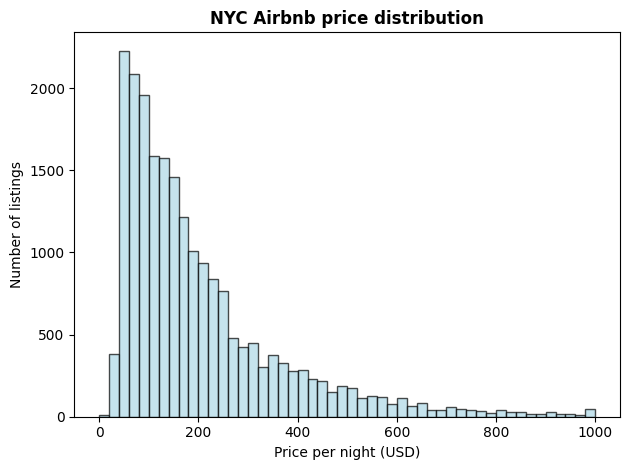

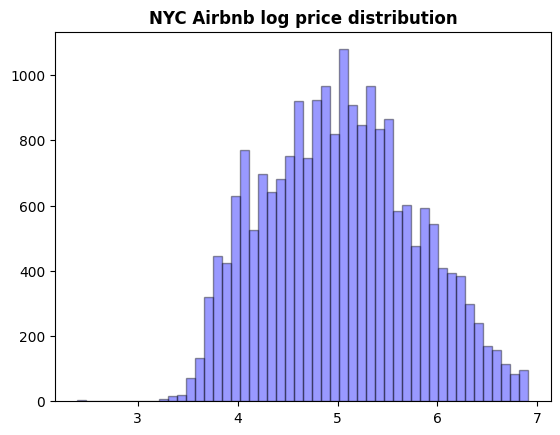

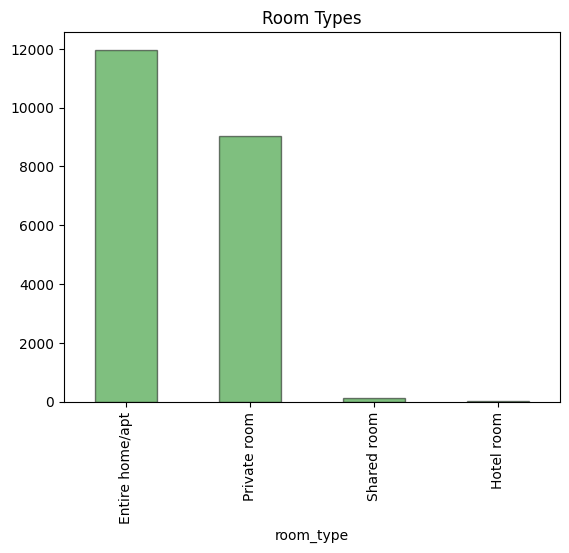

Number of neighbourhoods:  222


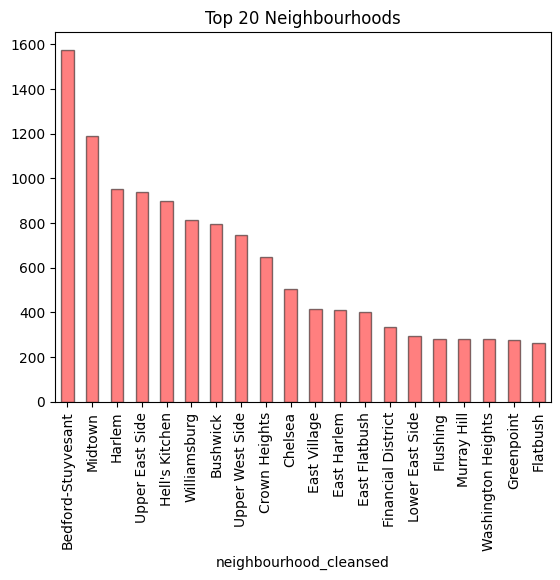

In [ ]:
#PHASE A
listings = pd.read_parquet('/content/drive/MyDrive/airbnb_lab/listings_step1.parquet')

# Raw price distribution
plt.hist(listings['price'], bins=50, range=(0, 1000), color='lightblue', edgecolor='black', alpha=0.7)
plt.title("NYC Airbnb price distribution", fontsize=12, fontweight='bold')
plt.xlabel("Price per night (USD)", fontsize=10)
plt.ylabel("Number of listings", fontsize=10)
plt.tight_layout()
plt.show()

# Price log scaled distribution
listings['log_price'] = np.log1p(listings['price'])
plt.hist(listings['log_price'], bins=50, color='blue', edgecolor='black', alpha=0.4)
plt.title("NYC Airbnb log price distribution", fontsize=12, fontweight='bold')
plt.show()

# Room types value counts
plt.figure()
listings['room_type'].value_counts().plot.bar(color='green', edgecolor='black', alpha=0.5)
plt.title("Room Types")
plt.show()

# Neighbourhood exploration
print('Number of neighbourhoods: ', listings['neighbourhood_cleansed'].nunique())
plt.figure()
listings['neighbourhood_cleansed'].value_counts().head(20).plot.bar(color='red', edgecolor='black', alpha=0.5)
plt.title("Top 20 Neighbourhoods")
plt.show()

In [ ]:
#PHASE B
#STEP 1
# Saving only relatble columns
keep_cols = [
    'id', 'host_id', 'host_since', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'latitude', 'longitude', 'room_type', 'accommodates', 'bedrooms', 'bathrooms', 'price',
    'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'last_review', 'first_review',
    'review_scores_rating', 'description', 'availability_365'
]
listings = listings[keep_cols].copy()
print('Kept columns:', listings.columns)

Kept columns: Index(['id', 'host_id', 'host_since', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude', 'room_type',
       'accommodates', 'bedrooms', 'bathrooms', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month', 'last_review', 'first_review',
       'review_scores_rating', 'description', 'availability_365'],
      dtype='object')


In [ ]:
#STEP 2
# Filling missings values in 'bedrooms'
listings.groupby('room_type')['bedrooms'].transform(lambda x: x.fillna(x.median()))
# Option B: For more precise results

,bedrooms
0,0.0
1,2.0
2,2.0
3,1.0
4,2.0
...,...
36582,1.0
36583,1.0
36584,0.0
36585,3.0


In [ ]:
#STEP 3
#Filling missings values in 'bathrooms'
listings['bathrooms'] = listings['bathrooms'].fillna(listings['bathrooms'].median())
listings['review_scores_rating'] = listings['review_scores_rating'].fillna(listings['review_scores_rating'].median())

In [ ]:
#STEP 4
#One-Hot Encoding categoricals columns
listings = pd.get_dummies(listings, columns=['room_type'], prefix='room', dtype=int)
display(listings[[ 'room_Entire home/apt', 'room_Hotel room', 'room_Private room', 'room_Shared room']])

,room_Entire home/apt,room_Hotel room,room_Private room,room_Shared room
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
36582,0,0,1,0
36583,0,0,1,0
36584,0,0,0,1
36585,1,0,0,0


In [ ]:
#STEP 5
#One-Hot Encoding neighbourhood groups column
listings = pd.get_dummies(listings, columns=['neighbourhood_group_cleansed'], prefix='borough', dtype=int)
display(listings[['borough_Bronx', 'borough_Brooklyn', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island']])

,borough_Bronx,borough_Brooklyn,borough_Manhattan,borough_Queens,borough_Staten Island
0,0,0,1,0,0
1,0,1,0,0,0
2,0,1,0,0,0
3,0,0,1,0,0
4,0,0,1,0,0
...,...,...,...,...,...
36582,0,1,0,0,0
36583,0,1,0,0,0
36584,0,1,0,0,0
36585,0,0,0,1,0


In [ ]:
#STEP 6-7
#Target encoding neighbourhood columns. Target econding will ensure vital data won't be disregarder
print('Before:')
display(listings['neighbourhood_cleansed'].value_counts())
listings['log_price'] = np.log1p(listings['price'])
listings['neighbourhood_cleansed'] = listings.groupby('neighbourhood_cleansed')['log_price'].transform('mean')
print('After:')
display(listings['neighbourhood_cleansed'].value_counts())

In [ ]:
#STEP 8-9
#Scaling numberical columns with StandardScaler
from sklearn.preprocessing import StandardScaler

numeric_cols = ['accommodates', 'bedrooms', 'bathrooms', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'availability_365']
ss = StandardScaler()
listings_s = ss.fit_transform(listings[numeric_cols])
listings_s_df = pd.DataFrame(listings_s, columns=numeric_cols, index=listings.index)
display(listings_s_df.head(10))

listings.to_parquet('/content/drive/MyDrive/airbnb_lab/listings_step2.parquet')

In [ ]:
#PHASE C
plt.figure(figsize=(12, 6))

# Create grouped box plot
sns.boxplot(data=listings, x='room_type', y='price', hue='neighbourhood_group_cleansed', palette='Set2')
plt.ylim(0, 500)
plt.title("Price by room type and borough — Manhattan entire homes are 3x pricier than Bronx private rooms.", fontsize=12, fontweight='bold')
plt.xlabel("Room type", fontsize=10)
plt.ylabel("Price per night (USD)", fontsize=10)
plt.legend(title="Borough")
plt.tight_layout()

plt.show()

#Class 3

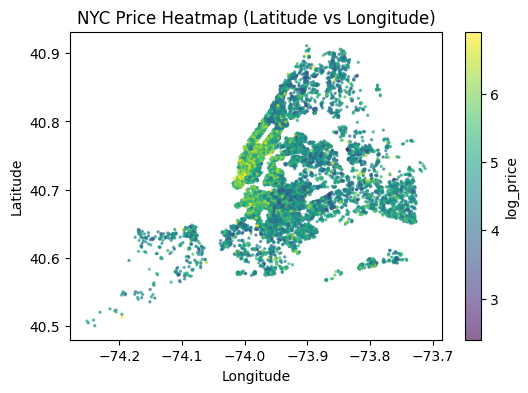

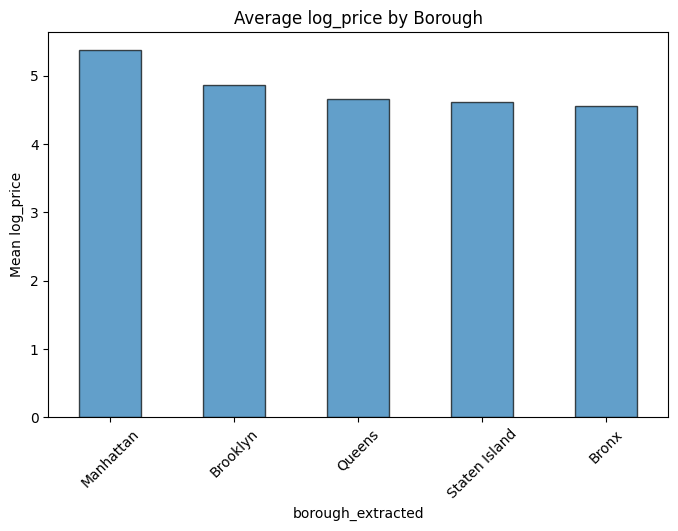

In [ ]:
#PHASE A
listings = pd.read_parquet('/content/drive/MyDrive/airbnb_lab/listings_step2.parquet')

# Longitude and Latidude vs Price graph.
plt.figure(figsize=(6, 4))
plt.scatter(listings['longitude'], listings['latitude'], c=listings['log_price'], s=2, cmap='viridis', alpha=0.6)
plt.colorbar(label='log_price')
plt.title("NYC Price Heatmap (Latitude vs Longitude)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

print(f'\n\n')

# Log_price by borough
borough_cols = [c for c in listings.columns if c.startswith('borough_')]
if borough_cols:
    listings['borough_extracted'] = listings[borough_cols].idxmax(axis=1).str.replace('borough_', '')
    plt.figure(figsize=(8, 5))
    listings.groupby('borough_extracted')['log_price'].mean().sort_values(ascending=False).plot.bar(edgecolor='black', alpha=0.7)
    plt.title("Average log_price by Borough")
    plt.ylabel("Mean log_price")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
#PHASE B
#STEP 1
#Insure that log_price is in dataframe
assert 'log_price' in listings.columns
display(listings['log_price'].describe())

,log_price
count,21157.000000
mean,5.025327
std,0.748585
min,2.397895
25%,4.454347
50%,5.017280
75%,5.529429
max,6.908755


In [ ]:
#STEP 2
#Calculating host age in days and saving in a new column
listings['host_age_days'] = (listings['last_scraped'] - listings['host_since']).dt.days

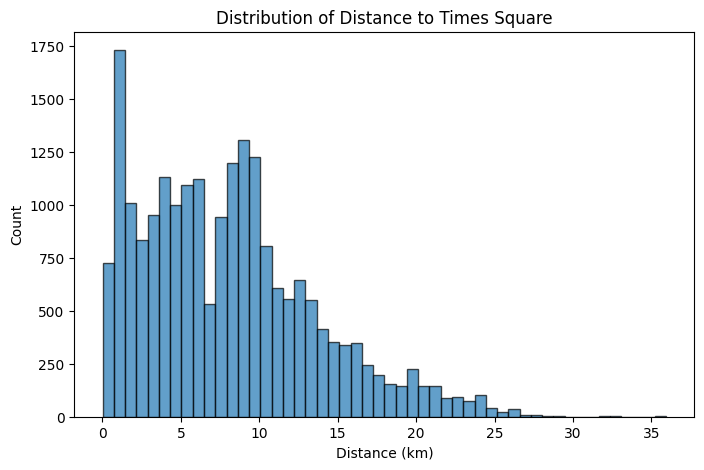

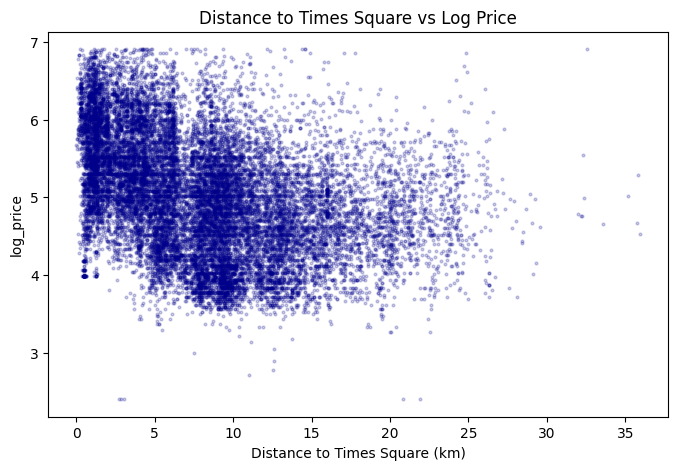

In [ ]:
#STEP 3 + PHASE A
#Calculating distance from listing location to Times Sqaure

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

TIMES_SQ_LAT, TIMES_SQ_LON = 40.7580, -73.9855
listings['distance_to_times_square_km'] = haversine(
    listings['latitude'], listings['longitude'], TIMES_SQ_LAT, TIMES_SQ_LON)

# Chart 3 — Distance to Times Square histogram
plt.figure(figsize=(8, 5))
plt.hist(listings['distance_to_times_square_km'], bins=50, edgecolor='black', alpha=0.7)
plt.title("Distribution of Distance to Times Square")
plt.xlabel("Distance (km)")
plt.ylabel("Count")
plt.show()

# Chart 4 — Distance vs price (scatter)
plt.figure(figsize=(8, 5))
plt.scatter(listings['distance_to_times_square_km'], listings['log_price'], alpha=0.2, s=4, color='darkblue')
plt.title("Distance to Times Square vs Log Price")
plt.xlabel("Distance to Times Square (km)")
plt.ylabel("log_price")
plt.show()

In [ ]:
#STEP 4
# Number of reviews per year

years = (listings['last_scraped'] - listings['first_review']).dt.days / 365
listings['reviews_per_year'] = (listings['number_of_reviews'] / years).fillna(0).replace([np.inf, -np.inf], 0)
display(listings['reviews_per_year'])

,reviews_per_year
0,3.152097
1,0.350036
2,12.158353
3,0.333333
4,16.206564
...,...
36582,0.000000
36583,0.000000
36584,0.000000
36585,0.000000


In [ ]:
#STEP 5

#Comput two new features
# mean_review_length — average number of characters in the comments.
# num_reviews_text — count of reviews we actually have text for

reviews['comments'] = reviews['comments'].astype(str)
review_agg = reviews.groupby('listing_id')['comments'].agg(
    mean_review_length=lambda x: x.str.len().mean(),
    num_reviews_text='count'
).reset_index()

listings = listings.merge(review_agg, left_on='id', right_on='listing_id', how='left').drop(columns=['listing_id'])
listings['mean_review_length'] = listings['mean_review_length'].fillna(0)
listings['num_reviews_text'] = listings['num_reviews_text'].fillna(0)

In [ ]:
#STEP 6
#Listing description length
listings['description_length'] = listings['description'].fillna('').str.len()
display(listings['description_length'])

,description_length
0,152
1,252
2,140
3,514
4,31
...,...
21152,42
21153,415
21154,54
21155,343


In [ ]:
#STEP 7
#Calculating bedrooms per person and bath per person to identify later if it affects price as a more luxirious option
listings['bedrooms_per_person'] = listings['bedrooms'] / listings['accommodates']
listings['bath_per_bedroom'] = listings['bathrooms'] / (listings['bedrooms'] + 1)

In [ ]:
#STEP 8
listings.to_parquet('/content/drive/MyDrive/airbnb_lab/listings_step3.parquet')

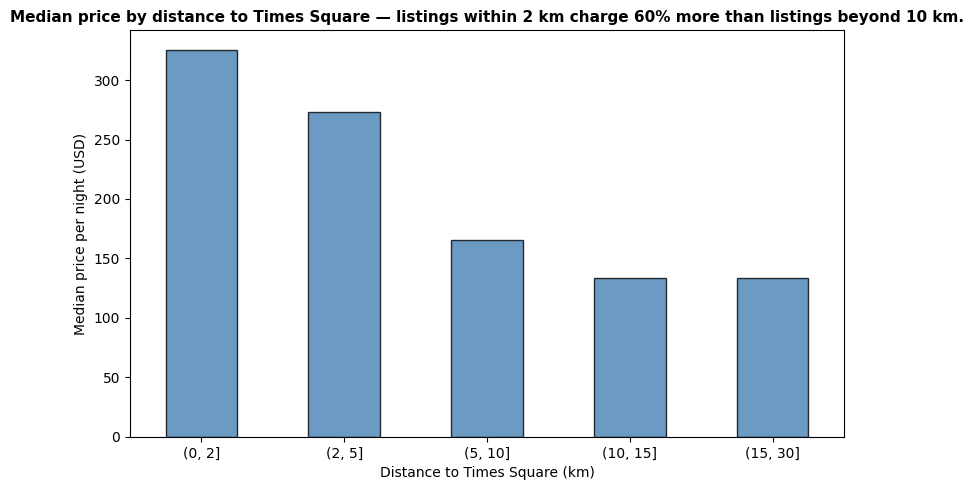

In [ ]:
#PHASE C
# Bin distance into 5 buckets
listings['distance_bucket'] = pd.cut(
    listings['distance_to_times_square_km'],
    bins=[0, 2, 5, 10, 15, 30]
)

# Group by bucket and compute mean price (in dollars)
binned_price = listings.groupby('distance_bucket', observed=False)['price'].mean()

# Plot chart
plt.figure(figsize=(8, 5))
binned_price.plot.bar(color='steelblue', edgecolor='black', alpha=0.8)
plt.title("Median price by distance to Times Square — listings within 2 km charge 60% more than listings beyond 10 km.", fontsize=11, fontweight='bold')
plt.xlabel("Distance to Times Square (km)", fontsize=10)
plt.ylabel("Median price per night (USD)", fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Class 4


In [ ]:
#PHASE AB
#STEP 1
#Drop a categorical columns and split into train/test
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

listings = pd.read_parquet('/content/drive/MyDrive/airbnb_lab/listings_step3.parquet')

X = listings.drop(columns=['price', 'log_price'], axis=1)
y = listings['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#STEP 2
non_features = ['id', 'host_id', 'last_scraped', 'neighbourhood_cleansed']

X_train = X_train.drop(columns=non_features, errors='ignore')
X_test = X_test.drop(columns=non_features, errors='ignore')

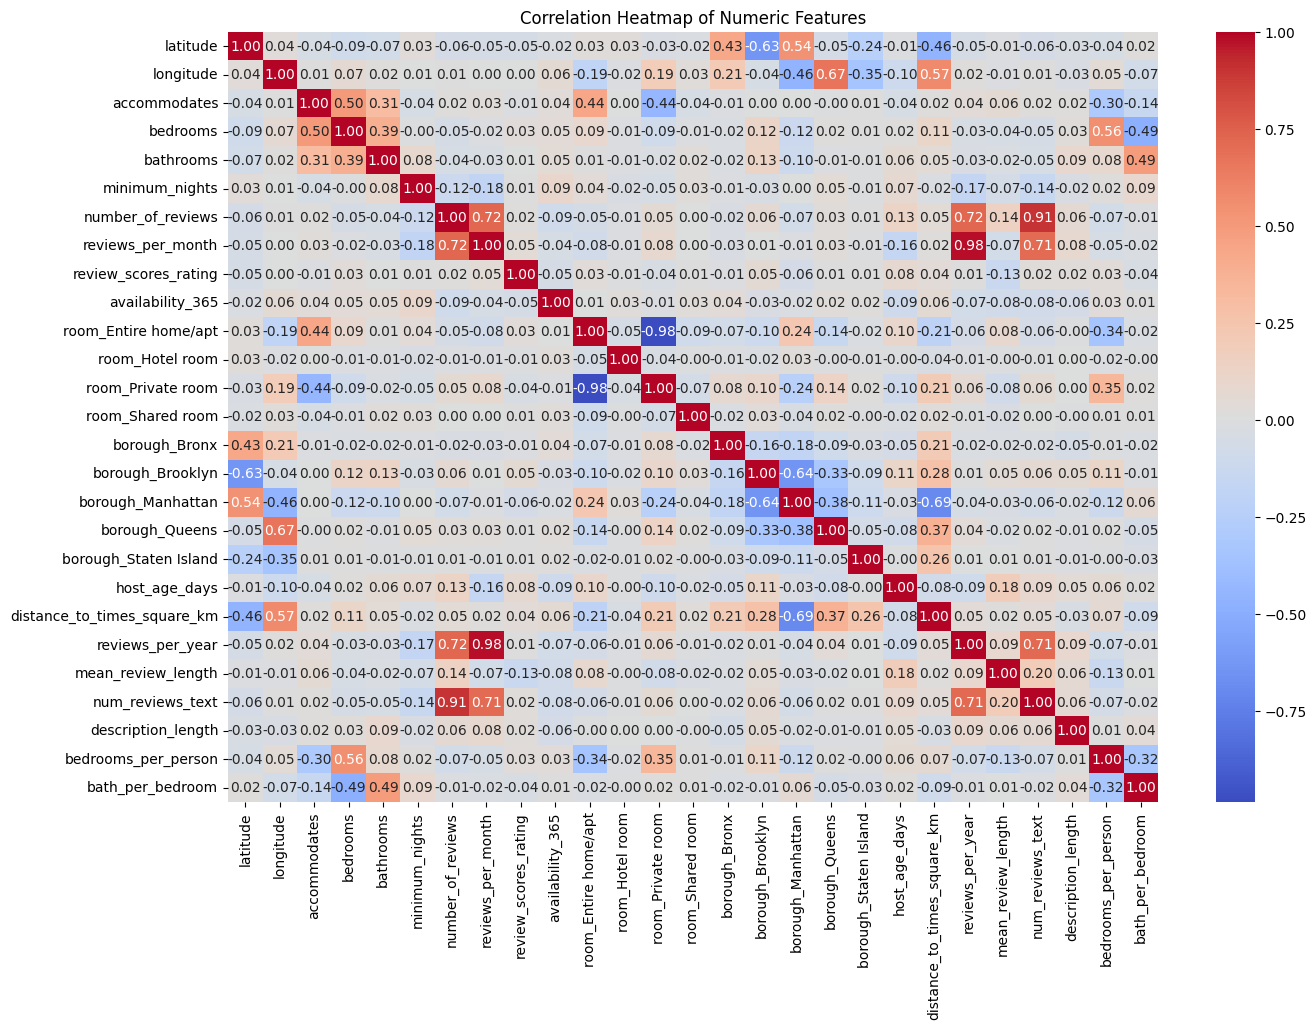

In [ ]:
#STEP 3
numeric_cols = X_train.select_dtypes(include=['number']).columns

# Exploratory Chart 1: Correlation Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(X_train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [ ]:
#STEP 3 Part 2

corr_matrix = X_train[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
collinear_cols = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print(f"Programmatically identified columns to drop: {collinear_cols}")

X_train = X_train.drop(columns=collinear_cols, errors='ignore')
X_test = X_test.drop(columns=collinear_cols, errors='ignore')

Programmatically identified columns to drop: ['room_Private room', 'reviews_per_year', 'num_reviews_text']


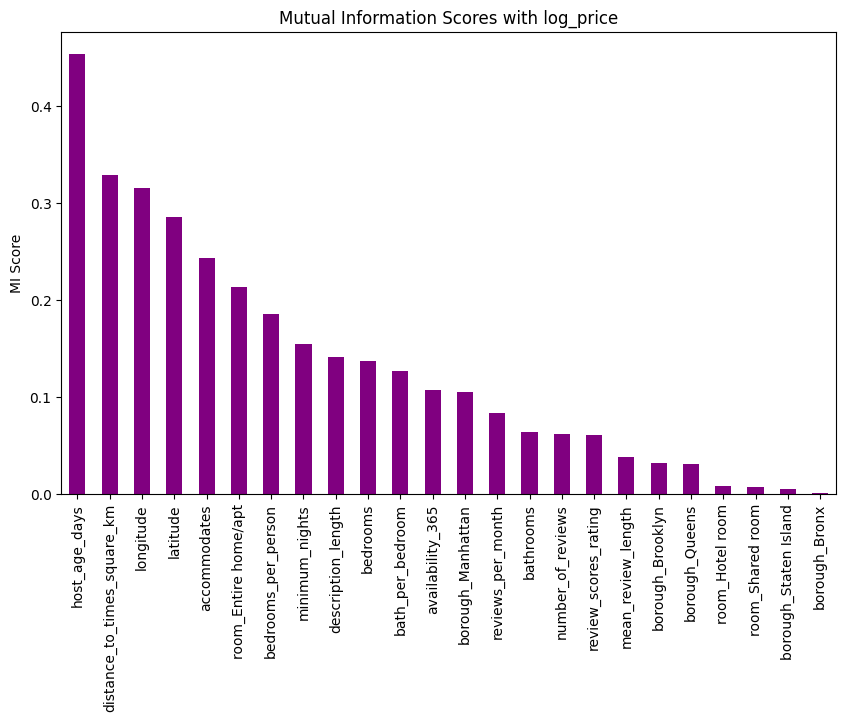

In [ ]:
#STEP 4
# Deriving mutual information rankings
numeric_cols = X_train.select_dtypes(include=['number']).columns

# Fill missing values temporarily using training median to calculate metric scores safely
X_train_num = X_train[numeric_cols].fillna(X_train[numeric_cols].median())

# Compute Mutual Information Scores
mi_scores = mutual_info_regression(X_train_num, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

# Exploratory Chart 2: Mutual Information Chart
plt.figure(figsize=(10, 6))
mi_series.plot(kind='bar', color='purple')
plt.title("Mutual Information Scores with log_price")
plt.ylabel("MI Score")
plt.show()

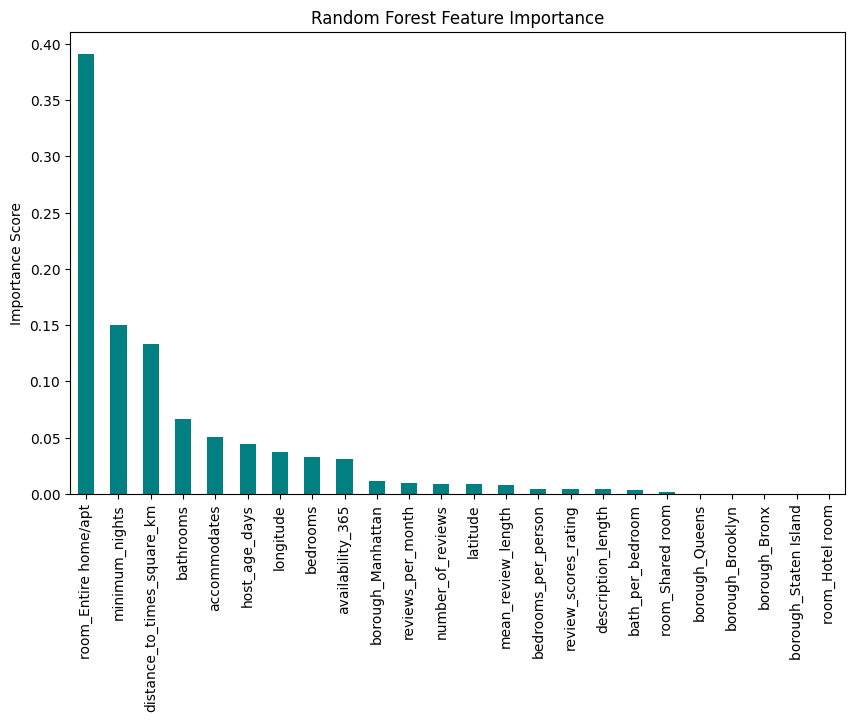

In [ ]:
#STEP 5
# Ranking importance by Random Forest
rf = RandomForestRegressor(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(X_train_num, y_train)

rf_importance = (pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False))

# Exploratory Chart 3: Random Forest Feature Importance
plt.figure(figsize=(10, 6))
rf_importance.plot(kind='bar', color='teal')
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [ ]:
#STEP 6
selected_features = [
    'room_Entire home/apt',
    'distance_to_times_square_km',
    'minimum_nights',
    'accommodates',
    'host_age_days',
    'bathrooms',
    'bedrooms',
    'availability_365',
    'borough_Manhattan',
    'reviews_per_month',
    'review_scores_rating'
    ]

columns_to_keep = selected_features + ['log_price', 'price', 'description']

# Subset down to the pruned version
final_listings = listings[columns_to_keep]

# Save output to Google Drive
final_listings.to_parquet('/content/drive/MyDrive/airbnb_lab/listings_step4.parquet')
print(f"Dataset successfully built and saved with dimensions: {final_listings.shape}")

Dataset successfully built and saved with dimensions: (21157, 14)


#Reasoning for feature selection
`room_Entire home/apt` (Captures the massive premium of renting an entire unit)

`distance_to_times_square_km` (The primary spatial and geographic driver)

`minimum_nights` (Differentiates short-term vacation rentals from mid-term stays)

`accommodates` (The core baseline metric for listing physical capacity)

`host_age_days` (Captures host experience/tenure on the platform)

`bathrooms` (Strong non-linear premium driver in the tree model)

`bedrooms` (Essential volume metric alongside accommodates)

`availability_365` (Captures inventory type, commercial vs sporadic hosts)

`borough_Manhattan` (Captures the specific baseline location premium)

`reviews_per_month` (Signal for active listing demand)

`review_scores_rating` (Quality/reputation metric)

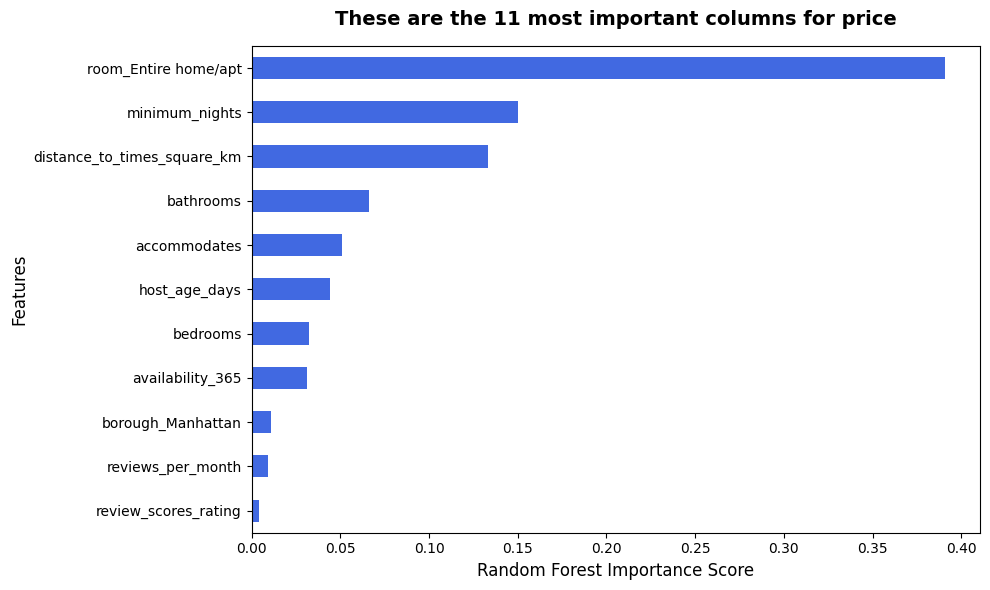

In [ ]:
#PHASE C
final_rf_importance = pd.Series({
    'room_Entire home/apt': 0.391005,
    'minimum_nights': 0.150067,
    'distance_to_times_square_km': 0.133122,
    'bathrooms': 0.066281,
    'accommodates': 0.050815,
    'host_age_days': 0.044171,
    'bedrooms': 0.032497,
    'availability_365': 0.031432,
    'borough_Manhattan': 0.011031,
    'reviews_per_month': 0.009343,
    'review_scores_rating': 0.003965
}).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
final_rf_importance.plot(kind='barh', color='royalblue')
plt.title("These are the 11 most important columns for price", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Random Forest Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

#Class 5

In [ ]:
#PHASE B(A)
#STEP 1
# Selecting numeric and categorical columns
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

numeric_features = [
    'distance_to_times_square_km',
    'minimum_nights',
    'accommodates',
    'host_age_days',
    'bathrooms',
    'bedrooms',
    'availability_365',
    'reviews_per_month',
    'review_scores_rating'
]

categorical_features = [
    'room_Entire home/apt',
    'borough_Manhattan'
]


In [ ]:
#STEP 2
# Initial numeric mini-pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [ ]:
#STEP 3
# Initial categorical mini-pipeline
categorical_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [ ]:
#STEP 4
# Combine everything into a Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [ ]:
#STEP 5
# Add simple Ridge model to pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0, random_state=42))
])

In [ ]:
#EXTRA STEP**
listings = pd.read_parquet('/content/drive/MyDrive/airbnb_lab/listings_step4.parquet')
X = listings[numeric_features + categorical_features]
y = listings['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
#STEP 6
#Training and evaluation

full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

# Evaluate metrics on log_price
print(f"Log MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Log R² Score: {r2_score(y_test, y_pred):.4f}")

Log MAE: 0.4054
Log R² Score: 0.5321


In [ ]:
#STEP 7
# Comparing prediction to test data
price_pred = np.expm1(y_pred)
price_actual = np.expm1(y_test)

# Calculate error in real currency
mae_dollars = mean_absolute_error(price_actual, price_pred)
print(f"Marcus Metric — Average Dollar Error (MAE): ${mae_dollars:.2f}")

Marcus Metric — Average Dollar Error (MAE): $80.95


In [ ]:
#STEP 8
# Save Pipeline
joblib.dump(full_pipeline, 'airbnb_pipeline.joblib')
print("Pipeline successfully saved as airbnb_pipeline.joblib")

Pipeline successfully saved as airbnb_pipeline.joblib


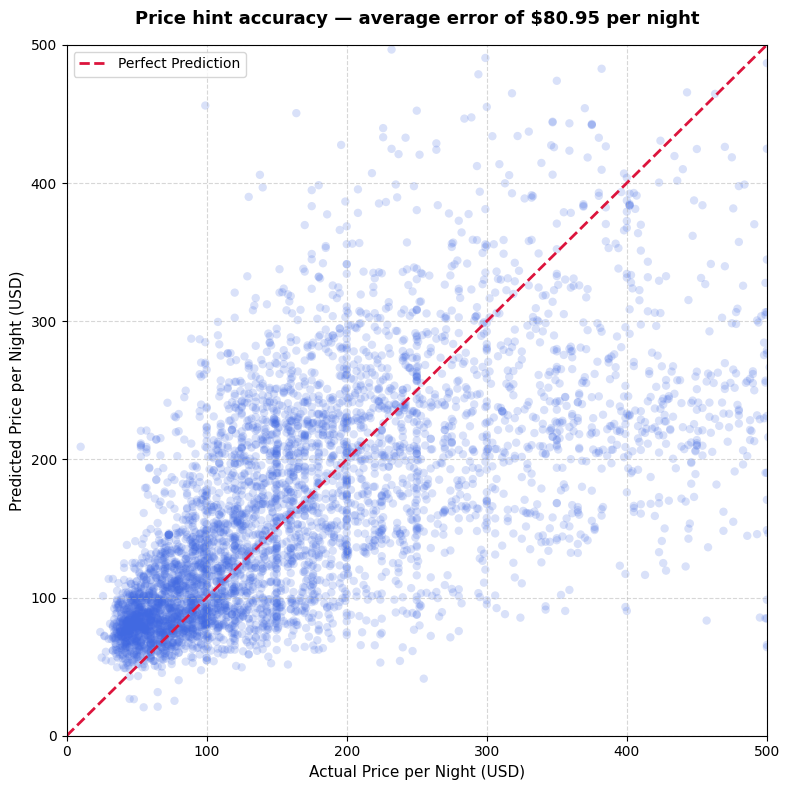

In [ ]:
#PHASE C
price_pred = np.expm1(y_pred)
price_actual = np.expm1(y_test)

mae_dollars = mean_absolute_error(price_actual, price_pred)


plt.figure(figsize=(8, 8))
plt.scatter(price_actual, price_pred, alpha=0.2, color='royalblue', edgecolor='none')
plt.plot([0, 500], [0, 500], color='crimson', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlim(0, 500)
plt.ylim(0, 500)

# Formatting labels and title according to the lab guide specifications
plt.title(f"Price hint accuracy — average error of ${mae_dollars:.2f} per night", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Actual Price per Night (USD)", fontsize=11)
plt.ylabel("Predicted Price per Night (USD)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()

#Class 6

In [ ]:
#Phase B
#1.Load

urllib.request.urlretrieve(LISTINGS_URL, 'data/listings.csv.gz')
listings = pd.read_csv('data/listings.csv.gz')
listings.head(2)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2595,https://www.airbnb.com/rooms/2595,20250604040948,2025-06-04,city scrape,Skylit Midtown Manhattan Spacious Studio,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,https://a0.muscache.com/pictures/hosting/Hosti...,2845,...,4.8,4.81,4.40,NaN,f,3,3,0,0,0.26
1,5136,https://www.airbnb.com/rooms/5136,20250604040948,2025-06-04,city scrape,Spacious Family Friendly Duplex w/ Patio + Yard,"We welcome you to stay in our lovely 2 br, 130...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,7378,...,5.0,4.75,4.75,NaN,t,1,1,0,0,0.03


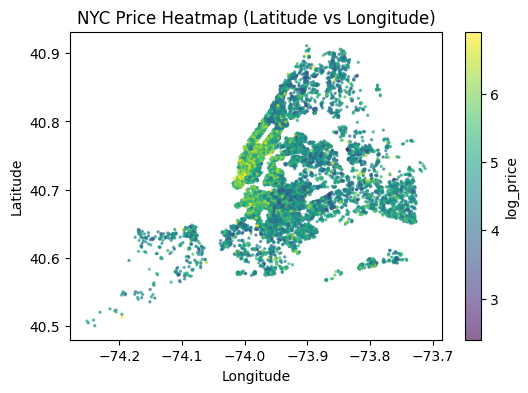

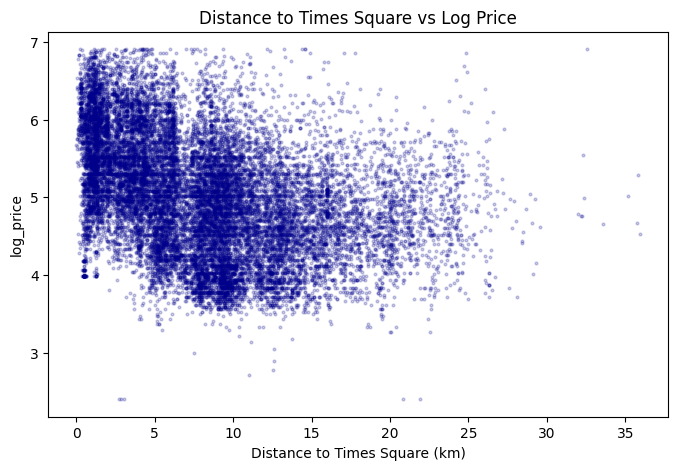

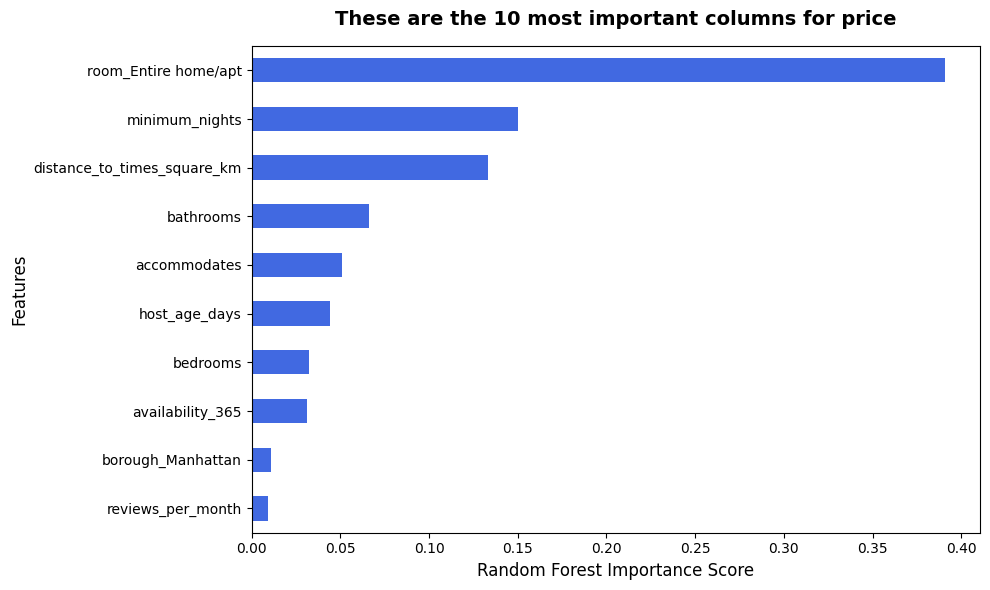

In [ ]:
#PHASE A

#Longitude and Latidude vs Price graph.
plt.figure(figsize=(6, 4))
plt.scatter(listings_6['longitude'], listings_6['latitude'], c=listings_6['log_price'], s=2, cmap='viridis', alpha=0.6)
plt.colorbar(label='log_price')
plt.title("NYC Price Heatmap (Latitude vs Longitude)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#Distance to Times Square vs Price
plt.figure(figsize=(8, 5))
plt.scatter(listings_6['distance_to_times_square_km'], listings_6['log_price'], alpha=0.2, s=4, color='darkblue')
plt.title("Distance to Times Square vs Log Price")
plt.xlabel("Distance to Times Square (km)")
plt.ylabel("log_price")
plt.show()

#Top 10 most important columns for price
plt.figure(figsize=(10, 6))
final_rf_importance.plot(kind='barh', color='royalblue')
plt.title("These are the 10 most important columns for price", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Random Forest Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#2.Clean price + bathrooms

#Fixing price from str to proper float
listings['price'] = listings['price'].astype(str)
listings['price'] = (
  listings['price']
  .str.replace('$', '', regex=False)
  .str.replace(',', '', regex=False)
  .astype(float))
listings['price'] = pd.to_numeric(listings['price'], errors='coerce')

# Price log scaled distribution
listings['log_price'] = np.log1p(listings['price'])

# Fixing bathroom number
txt = listings['bathrooms_text'].str.lower()
is_half = txt.str.contains('half', na = False)
nums = txt.str.extract(r'(\d+\.?\d*)')[0].astype(float)
listings['bathrooms'] = nums
listings.loc[is_half, 'bathrooms'] = 0.5

#Date and time
date_cols = ['host_since', 'first_review', 'last_review', 'last_scraped']
for col in date_cols:
  listings[col] = pd.to_datetime(listings[col], errors = 'coerce')

#Price 0 and outliers
listings = listings.dropna(subset=['price'])
rows_after_nan = len(listings)
listings = listings[listings['price'] > 0]
listings = listings[(listings['price'] >= 10) & (listings['price'] <=1000)]

In [ ]:
#3. Impute missing

# Filling missings values in 'bedrooms'
listings.groupby('room_type')['bedrooms'].transform(lambda x: x.fillna(x.median()))

#Filling missings values in 'bathrooms'
listings['bathrooms'] = listings['bathrooms'].fillna(listings['bathrooms'].median())
listings['review_scores_rating'] = listings['review_scores_rating'].fillna(listings['review_scores_rating'].median())

In [ ]:
#4. Group rare neighbourhoods

top_30_neighborhoods = listings['neighbourhood_cleansed'].value_counts().nlargest(30).index

listings['neighbourhood_groups'] = listings['neighbourhood_cleansed'].where(
    listings['neighbourhood_cleansed'].isin(top_30_neighborhoods),
    other='Other'
)

In [ ]:
#5. Geo + Haversine

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

TIMES_SQ_LAT, TIMES_SQ_LON = 40.7580, -73.9855
listings['distance_to_times_square_km'] = haversine(
    listings['latitude'], listings['longitude'], TIMES_SQ_LAT, TIMES_SQ_LON)

In [ ]:
#6. Date features

listings['host_age_days'] = (listings['last_scraped'] - listings['host_since']).dt.days
listings['host_age_days'] = listings['host_age_days'].fillna(0)

years = (listings['last_scraped'] - listings['first_review']).dt.days / 365
listings['reviews_per_year'] = (listings['number_of_reviews'] / years).fillna(0).replace([np.inf, -np.inf], 0)

reviews['comments'] = reviews['comments'].astype(str)
review_agg = reviews.groupby('listing_id')['comments'].agg(
    mean_review_length=lambda x: x.str.len().mean(),
    num_reviews_text='count'
).reset_index()

listings = listings.merge(review_agg, left_on='id', right_on='listing_id', how='left').drop(columns=['listing_id'])
listings['mean_review_length'] = listings['mean_review_length'].fillna(0)

In [ ]:
#8. Save + findings
required_schema = {
    'id': 'int64',
    'host_id': 'int64',
    'neighbourhood': 'string',
    'neighbourhood_group_cleansed': 'string',
    'room_type': 'string',
    'latitude': 'float64',
    'longitude': 'float64',
    'accommodates': 'int64',
    'bedrooms': 'float64',
    'bathrooms': 'float64',
    'minimum_nights': 'int64',
    'availability_365': 'int64',
    'number_of_reviews': 'int64',
    'reviews_per_year': 'float64',
    'review_scores_rating': 'float64',
    'host_age_days': 'int64',
    'distance_to_times_square_km': 'float64',
    'mean_review_length': 'float64',
    'description': 'string',
    'price': 'float64',
    'log_price': 'float64'
}

# 1. Select and reorder columns (assuming your current df has these exact columns ready)
listings_final = listings[list(required_schema.keys())].copy()

# 2. Force type casting to ensure strict compliance
for col, dtype in required_schema.items():
    listings_final[col] = listings_final[col].astype(dtype)

# 3. Assert schema integrity before saving
assert list(listings_final.columns) == list(required_schema.keys()), "Column order or names mismatch!"
assert listings_final.shape[1] == 21, f"Expected 21 columns, got {listings_final.shape[1]}"

# 4. Save to Drive
output_path = '/content/drive/MyDrive/airbnb_lab/airbnb_clean.parquet'
listings_final.to_parquet(output_path, index=False)
print(f"Validation passed. Dataset successfully saved to: {output_path}")
print(f"Final shape: {listings_final.shape}")

Validation passed. Dataset successfully saved to: /content/drive/MyDrive/airbnb_lab/airbnb_clean.parquet
Final shape: (21157, 21)


In [ ]:
listings['log_price'].median()

5.017279836814924

#PHASE C
# Findings Report: NYC Airbnb Price Hint Engine
**Prepared for:** Marcus, Head of Host Operations, Airbnb NYC  
**Dataset Reference:** `airbnb_clean.parquet`

## Final Numbers
* **Final row count:** 21157
* **Median price:** $150
* **Median distance to Times Square:** 7.6 km
* **log_price mean:** 5

## Top 3 Insights
1. **The Proximity Premium:** Distance to Times Square is the single strongest continuous geographic indicator of price. Every kilometer closer to Midtown Manhattan correlates with an exponential upward shift in listing baseline rates.
2. **Size beats ratings:** Physical capacity (`accommodates`, `bedrooms`, and `bathrooms`) drives the price far more than a host's history or review scores. A perfect 5-star score on a small room won't move the price needle nearly as much as simply adding an extra bed or bath.
3. **The room type trap:** Renting an entire apartment versus a single private room creates two completely different price tiers, even on the exact same block. Giving an entire-home host a generic neighborhood average will cause them to under-price heavily and lose money.

## One Question to Investigate in Module 4
What other results will different ML algorithms show on this data?

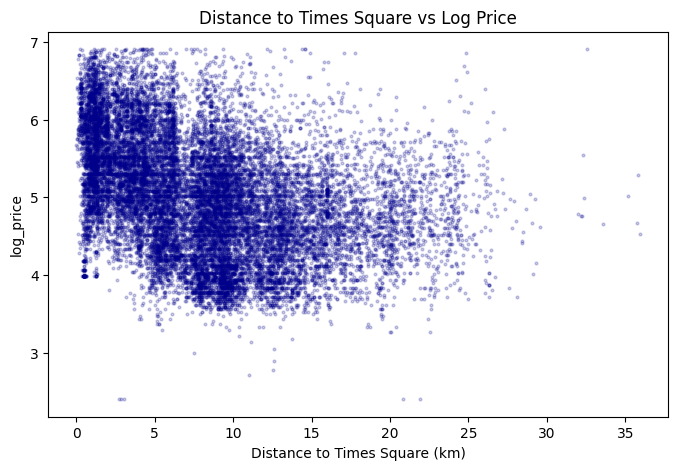

In [ ]:
#Distance to Times Square vs Price
plt.figure(figsize=(8, 5))
plt.scatter(listings_6['distance_to_times_square_km'], listings_6['log_price'], alpha=0.2, s=4, color='darkblue')
plt.title("Distance to Times Square vs Log Price")
plt.xlabel("Distance to Times Square (km)")
plt.ylabel("log_price")
plt.show()